In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/dataset.csv")

print(df.shape)
print(df.info())
print(df.head())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [4]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)*100
#this will check how many customer churned vs stayed and normalize will convert it to the percentage count #

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

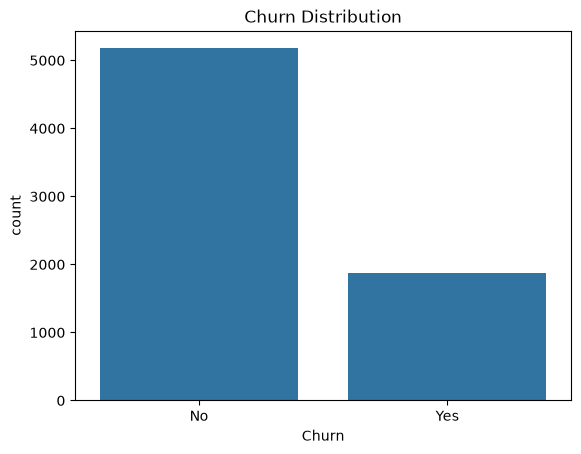

In [7]:
sns.countplot(x='Churn',data=df)
plt.title('Churn Distribution')
plt.show()

In [8]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values count:", df['TotalCharges'].isnull().sum())

Missing values count: 11


In [ ]:
numeric_cols = ['tenure','MonthlyCharges','TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
#confirm these NaNs belong to tenure=0 customers filllings the NaN
print(df.loc[df['TotalCharges'].isnull(),'tenure'].value_counts())

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
assert df['TotalCharges'].isnull().sum() == 0
print("Duplicates:", df.duplicated().sum())
print("Remaining missing values:", df.isnull().sum().sum())

In [ ]:
from pathlib import Path
Path("../data").mkdir(exist_ok=True)
df.to_csv("../data/cleaned_dataset.csv", index=False)

In [ ]:
# okay the cleaning dataset part is finished . this comment will serve as the checkpoint and the starting point for the EDA part #



C:\Users\user\AppData\Local\Temp\ipykernel_60836\4006788355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette=["#020b19", "#ff0000"])


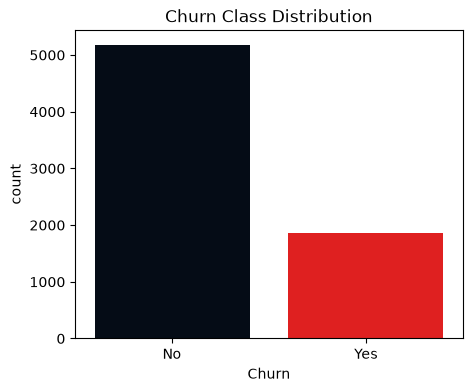

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

In [3]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette=["#020b19", "#ff0000"])
plt.title("Churn Class Distribution")
plt.show()
df["Churn"].value_counts(normalize=True).mul(100).round(1)

C:\Users\user\AppData\Local\Temp\ipykernel_60836\2782883928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="Greens_r")


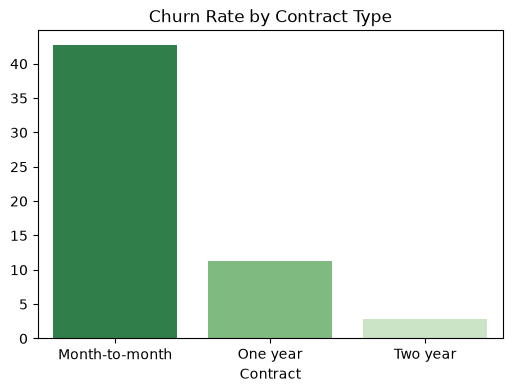

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

In [10]:
plt.figure(figsize=(6,4))
contract_churn = df.groupby("Contract")["Churn"].apply(lambda s: (s=="Yes").mean()*100).sort_values(ascending=False)
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette="Greens_r")
plt.title("Churn Rate by Contract Type")
plt.show()
contract_churn

C:\Users\user\AppData\Local\Temp\ipykernel_60836\131147935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pm_churn.index, y=pm_churn.values, palette="Greens_r")


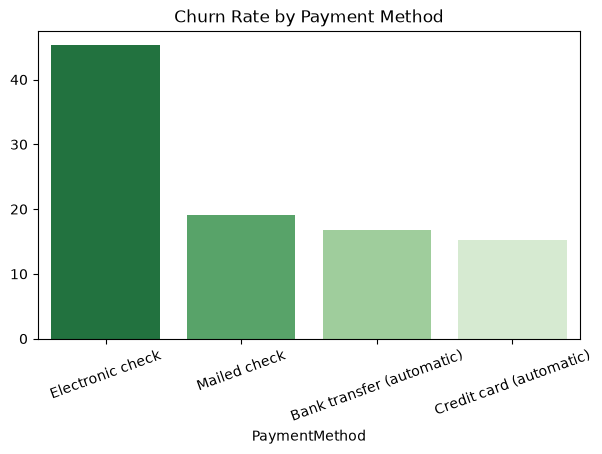

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

In [11]:
plt.figure(figsize=(7,4))
pm_churn = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s=="Yes").mean()*100).sort_values(ascending=False)
sns.barplot(x=pm_churn.index, y=pm_churn.values, palette="Greens_r")
plt.title("Churn Rate by Payment Method")
plt.xticks(rotation=20)
plt.show()
pm_churn